# Workshop 3 — CNN for Image Classification (Conceptual)
Same dataset (Fashion-MNIST), but now we use **convolutions**.

**Learning goals**
- Why CNN beats MLP on images: **local connectivity + weight sharing**
- Tune: **filters, kernel size, dropout, learning rate**
- Optional: visualize **feature maps**


In [1]:
# If needed (most environments already have these)
# !pip -q install tensorflow matplotlib numpy

import os, math, time, random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices('GPU')))


TensorFlow: 2.20.0
GPU available: False


In [2]:
def show_images(images, labels=None, class_names=None, n=12, cols=6, title=None):
    plt.figure(figsize=(cols*2, math.ceil(n/cols)*2))
    for i in range(n):
        ax = plt.subplot(math.ceil(n/cols), cols, i+1)
        plt.imshow(images[i], cmap="gray")
        if labels is not None:
            lab = int(labels[i])
            if class_names is not None:
                plt.title(class_names[lab], fontsize=9)
            else:
                plt.title(str(lab), fontsize=9)
        plt.axis("off")
    if title:
        plt.suptitle(title)
    plt.show()

def plot_history(hist, metrics=("accuracy",), title="Training curves"):
    plt.figure(figsize=(7,4))
    for m in metrics:
        plt.plot(hist.history[m], label=f"train_{m}")
        val_key = "val_" + m
        if val_key in hist.history:
            plt.plot(hist.history[val_key], label=f"val_{m}")
    if "loss" in hist.history:
        plt.plot(hist.history["loss"], label="train_loss", linestyle="--")
        if "val_loss" in hist.history:
            plt.plot(hist.history["val_loss"], label="val_loss", linestyle="--")
    plt.title(title)
    plt.xlabel("epoch")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


Train: (60000, 28, 28) (60000,)
Test : (10000, 28, 28) (10000,)


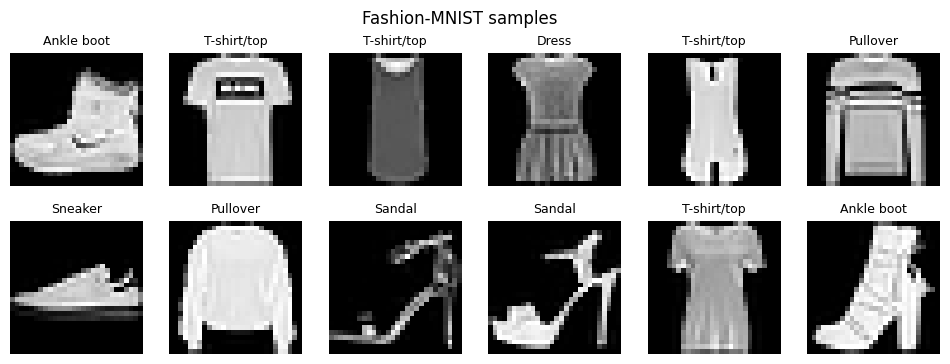

In [3]:
# Dataset: Fashion-MNIST (28x28 grayscale, 10 classes)
# - downloads automatically on first run
# - small enough for CPU, but still benefits from CNN
# - good to illustrate: linear vs MLP vs CNN

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

show_images(x_train[:12], y_train[:12], class_names, title="Fashion-MNIST samples")


In [4]:
# Split: train -> train/val, then keep test unseen
# Normalize pixel values to [0, 1]

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Create validation set (10k from training)
val_size = 10000
x_val, y_val = x_train[-val_size:], y_train[-val_size:]
x_tr,  y_tr  = x_train[:-val_size], y_train[:-val_size]

print("Train:", x_tr.shape, "Val:", x_val.shape, "Test:", x_test.shape)


Train: (50000, 28, 28) Val: (10000, 28, 28) Test: (10000, 28, 28)


In [9]:
# x_tr.shape print (number_of_images, height, width)   
print(x_tr[1].shape)

(28, 28)


## 0) Reshape data to (H, W, C) for CNN
since cnn expect (batch_size, height, width, channels)

In [6]:
x_tr_cnn  = x_tr[...,  np.newaxis]  # ... means keeping all existing dimension; and add one new channel at the end
x_val_cnn = x_val[..., np.newaxis]
x_test_cnn= x_test[...,np.newaxis]

print("Train CNN:", x_tr_cnn.shape)


Train CNN: (50000, 28, 28, 1)


## 1) Build a small CNN

In [10]:
# Hyperparameters to play with
LEARNING_RATE = 1e-3
BATCH_SIZE    = 128
EPOCHS        = 20
DROPOUT       = 0.3

model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(DROPOUT),
    layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## 2) Train
Try to beat your MLP score. If overfitting, increase dropout or use augmentation.

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.7978 - loss: 0.5593 - val_accuracy: 0.8738 - val_loss: 0.3545
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.8755 - loss: 0.3500 - val_accuracy: 0.8889 - val_loss: 0.3026
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.8927 - loss: 0.3011 - val_accuracy: 0.9006 - val_loss: 0.2695
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9028 - loss: 0.2700 - val_accuracy: 0.9050 - val_loss: 0.2595
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9111 - loss: 0.2453 - val_accuracy: 0.9105 - val_loss: 0.2482
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9174 - loss: 0.2255 - val_accuracy: 0.9086 - val_loss: 0.2506
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9245 - loss: 0.2086 - val_accuracy: 0.9199 - val_loss: 0.2228
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9282 - loss: 0.1969 - val_a

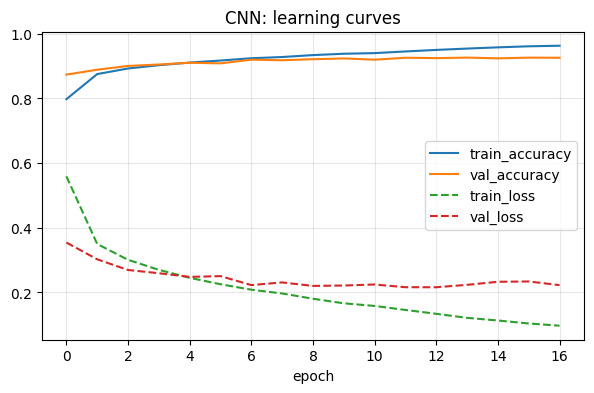

In [11]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
]

hist = model.fit(
    x_tr_cnn, y_tr,
    validation_data=(x_val_cnn, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

plot_history(hist, metrics=("accuracy",), title="CNN: learning curves")


In [12]:
def evaluate_and_report(model, x, y, name="set"):
    loss, acc = model.evaluate(x, y, verbose=0)
    print(f"{name:>5s}  loss={loss:.4f}  acc={acc:.4f}")
    return loss, acc

def confusion_matrix(model, x, y, class_names=None):
    y_prob = model.predict(x, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    cm = tf.math.confusion_matrix(y, y_pred, num_classes=y_prob.shape[1]).numpy()
    plt.figure(figsize=(6,5))
    plt.imshow(cm)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    if class_names is not None:
        plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right", fontsize=8)
        plt.yticks(range(len(class_names)), class_names, fontsize=8)
    plt.tight_layout()
    plt.show()
    return cm


## 3) Evaluate + confusion matrix

train  loss=0.1034  acc=0.9666
  val  loss=0.2162  acc=0.9248
 test  loss=0.2336  acc=0.9151


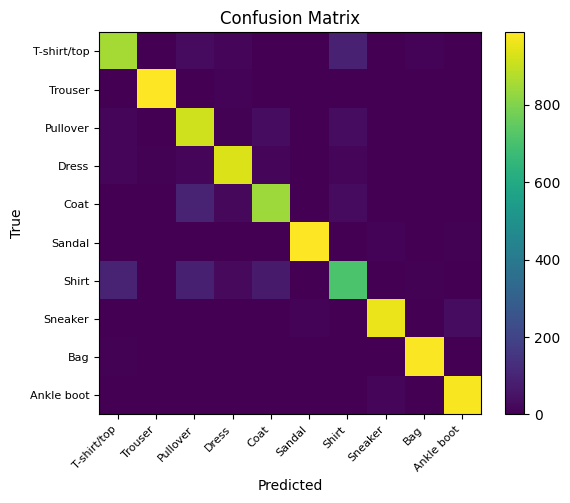

array([[855,   0,  27,  14,   2,   2,  90,   0,  10,   0],
       [  0, 987,   1,  10,   0,   0,   0,   0,   2,   0],
       [ 13,   1, 916,   6,  32,   0,  32,   0,   0,   0],
       [ 13,   5,  12, 936,  16,   0,  17,   0,   1,   0],
       [  1,   1, 100,  23, 843,   0,  29,   0,   3,   0],
       [  0,   0,   0,   0,   0, 987,   0,   8,   0,   5],
       [ 99,   2,  85,  26,  73,   0, 708,   0,   7,   0],
       [  0,   0,   0,   0,   0,  10,   0, 959,   0,  31],
       [  6,   2,   2,   1,   0,   3,   0,   2, 983,   1],
       [  0,   0,   0,   0,   0,   3,   1,  19,   0, 977]], dtype=int32)

In [13]:
evaluate_and_report(model, x_tr_cnn,  y_tr,  "train")
evaluate_and_report(model, x_val_cnn, y_val, "val")
evaluate_and_report(model, x_test_cnn,y_test,"test")

confusion_matrix(model, x_test_cnn, y_test, class_names=class_names)


## 4) (Optional) Data augmentation
Use **only** for training. Keep validation/test clean.

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.7376 - loss: 0.7014 - val_accuracy: 0.8197 - val_loss: 0.4922
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.8151 - loss: 0.5009 - val_accuracy: 0.8498 - val_loss: 0.4091
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.8348 - loss: 0.4469 - val_accuracy: 0.8601 - val_loss: 0.3719
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.8452 - loss: 0.4152 - val_accuracy: 0.8709 - val_loss: 0.3544
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.8561 - loss: 0.3892 - val_accuracy: 0.8769 - val_loss: 0.3297
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.8624 - loss: 0.3717 - val_accuracy: 0.8805 - val_loss: 0.3291
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.8681 - loss: 0.3589 - val_accuracy: 0.8795 - val_loss: 0.3292
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.8715 - loss: 0.3474 - 

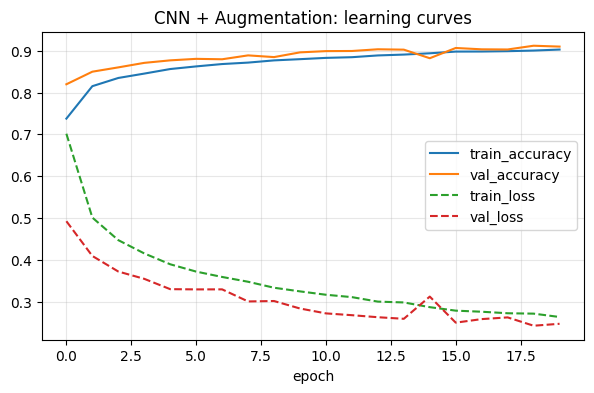

In [14]:
augment = keras.Sequential([
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomRotation(0.05),
])

aug_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    augment,

    layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(DROPOUT),
    layers.Dense(10, activation="softmax")
])

aug_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
]

hist2 = aug_model.fit(
    x_tr_cnn, y_tr,
    validation_data=(x_val_cnn, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

plot_history(hist2, metrics=("accuracy",), title="CNN + Augmentation: learning curves")


## 5) (Optional) Visualize feature maps from early layers

In [17]:
print(model.built)
print(model.inputs if hasattr(model, "inputs") else "no inputs")

True
[<KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor>]


In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,264,928 (4.83 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 843,286 (3.22 MB)

In [19]:
# Force the model to be called once to create cnn.input/cnn.output tensors
_ = model(tf.zeros((1, 28, 28, 1)))

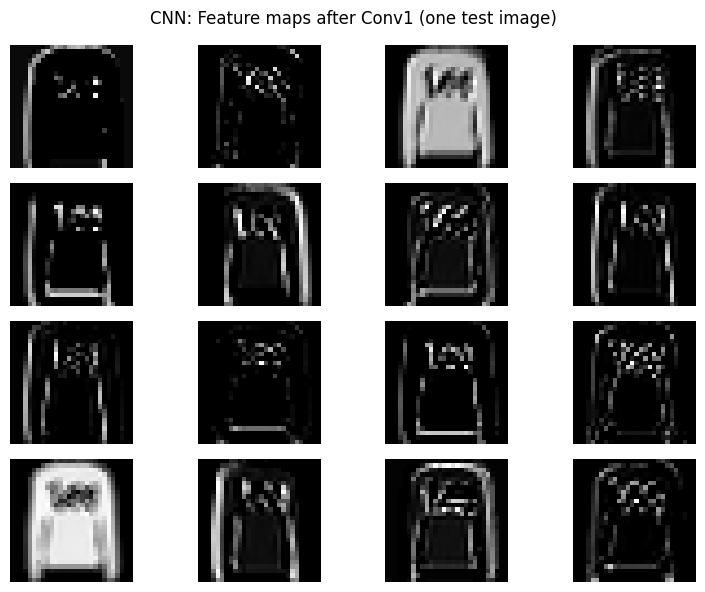

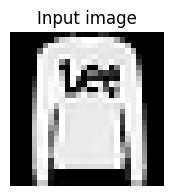

In [25]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Create a fresh symbolic input
inp = keras.Input(shape=(28, 28, 1))

x = inp
conv1_out = None

for layer in model.layers:
    x = layer(x)
    if layer.name == "conv2d":   # or: isinstance(layer, layers.Conv2D) and conv1_out is None
        conv1_out = x

feat_model = keras.Model(inputs=inp, outputs=conv1_out)

# Pick one test image
idx = 1
img = x_test_cnn[idx:idx+1]
feature_maps = feat_model.predict(img, verbose=0)[0]  # (H,W,C)

n = min(16, feature_maps.shape[-1])
plt.figure(figsize=(8,6))
for i in range(n):
    plt.subplot(4,4,i+1)
    plt.imshow(feature_maps[:,:,i], cmap="gray")
    plt.axis("off")
plt.suptitle("CNN: Feature maps after Conv1 (one test image)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(2,2))
plt.imshow(img[0,:,:,0], cmap="gray")
plt.title("Input image")
plt.axis("off")
plt.show()

## Exercises (in-class or homework)
1. Change conv filters: 16→32→64. Does accuracy improve?
2. Remove pooling and see training time + accuracy.
3. Compare CNN with and without augmentation.
4. Find 5 misclassified test images and explain why (visually).
